In [17]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import xtrack as xt
import xobjects as xo
import xpart as xp
import xcoll as xc
import json
import scipy.constants as sc

In [2]:
def remove_offmom_bpms_apers(line, exn=3.5e-6, nrj=21, pmass=0.938, bucket_height=3e-3, n_buckets=2):
    "Remove apertures of off-momentum BPMs which give flanges as bottlenecks"
    tt = line.get_table()
    tw = line.twiss()
    mask_disp = 5*np.sqrt(tw.betx*exn*pmass/nrj)+n_buckets*bucket_height*tw.dx > 0.025
    mask_bpm = ['bp' in name for name in tt.name]
    mask_aper = np.array(['aper' in name for name in tt.name])
    offmom_bpms = tt.name[mask_disp & mask_bpm & ~mask_aper]
    aper_to_remove = [f'{name}{suffix}' for name in offmom_bpms for suffix in ('.a_aper', '.b_aper')]
    line.remove(aper_to_remove)

In [3]:
error_variants = {
    'dipole_b3' : [0, 0, 1, 0, 0, 0],
    'dipole_b5' : [0, 0, 0, 0, 1, 0],
    'dipole_b3b5': [0, 0, 1, 0, 1, 0],
    'quadrupole_b4': [0, 0, 0, 1, 0, 0],
    'quadrupole_b6': [0, 0, 0, 0, 0, 1],
    'quadrupole_b4b6': [0, 0, 0, 1, 0, 1],
    'dipole_b3_quadrupole_b4': [0, 0, 1, 1, 0, 0],
    'all': [0, 0, 1, 1, 1, 1]
}
error_variant_name = 'all'
qx = 20.13
qy = 20.18
xi_x = 0.5
xi_y = 0.5

In [4]:
line = xt.load(Path('/Users/lisepauwels/phd/code/sps-xsuite-model/sps_with_aperture_inj_q20_beam_sagitta4.json'))
line = xt.load(Path('/Users/lisepauwels/phd/code/sps-xsuite-model/sps_q20_inj.json'))
env = line.env
cavity_elements, cavity_names = line.get_elements_of_type(xt.Cavity)
for name in cavity_names:
    line[name].frequency = 200e6
    line[name].lag = 180
    line[name].voltage = 0
# line['acl.31735'].voltage = 0 #setting 800 cav to 0V
line['actcse.31632'].voltage = 3.0e6

tw = line.twiss()
# remove_offmom_bpms_apers(line, exn=3.5e-6, nrj=21, pmass=0.938, bucket_height=3e-3, n_buckets=2)

# Installing errors
b1, b2, b3, b4, b5, b6 = error_variants[error_variant_name]
tte = env.elements.get_table()
mask_rbends = tte.element_type == 'RBend'
mask_quads = tte.element_type == 'Quadrupole'
mask_sextupoles = tte.element_type == 'Sextupole'

mba = tte.rows[mask_rbends].rows['mba.*'].name
mbb = tte.rows[mask_rbends].rows['mbb.*'].name
qf = tte.rows[mask_quads].rows['qf.*'].name
qd = tte.rows[mask_quads].rows['qd.*'].name
lsf = tte.rows[mask_sextupoles].rows['lsf.*'].name
lsd = tte.rows[mask_sextupoles].rows['lsd.*'].name

env.vars['qph_setvalue'] = 0.0
env.vars['qpv_setvalue'] = 0.0

# Set the strengths according to Hannes' measurements
for nn in mba:
    env[nn].knl = np.array([b1*0., b2*0., b3*2.12e-3, b4*0., b5*-5.74, b6*0.])

for nn in mbb:
    env[nn].knl = np.array([b1*0., b2*0., b3*-3.19e-3, b4*0., b5*-5.10, b6*0.])

for nn in qf:
    env[nn].knl = np.array([b1*0., b2*0., b3*0., b4*0.75e-1, b5*0., b6*-0.87e3])

for nn in qd:
    env[nn].knl = np.array([b1*0., b2*0., b3*0., b4*-2.03e-1, b5*0., b6*2.04e3])

env.vars['qph_setvalue'] = xi_x
env.vars['qpv_setvalue'] = xi_y
opt = line.match(
    method='6d', # <- passed to twiss
    vary=[
        xt.VaryList(['kqf0', 'kqd0'], step=1e-8, tag='quad'),
        xt.VaryList(['qph_setvalue', 'qpv_setvalue'], step=1e-4, tag='sext'),
    ],
    targets = [
        xt.TargetSet(qx=qx, qy=qy, tol=1e-6, tag='tune'),
        xt.TargetSet(dqx=xi_x*qx, dqy=xi_y*qy, tol=1e-2, tag='chrom'),
    ])

Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

/Users/lisepauwels/Xsuite/xtrack/xtrack/beam_elements/elements.py:2809: FutureWarning: The `Solenoid` element is deprecated. Use `VariableSolenoid` or `UniformSolenoid` instead.
  warn(


Done loading line from dict.           


Loading line from dict:   0%|          | 0/4037 [00:00<?, ?it/s]

Done loading line from dict.           
                                             
Optimize - start penalty: 13.73                             
Matching: model call n. 8 penalty = 2.6216e-03              
Optimize - end penalty:  0.00262155                            


In [5]:
num_particles  = 1
num_turns = 6000

sweep = 6000
plane = 'DPneg'
sweep = -abs(sweep) if plane == 'DPpos' else abs(sweep)

nemitt_x = 2e-6
nemitt_y = 2e-6
sigma_z = 0.224

In [6]:
#Installing TIDP (off-momentum block/collimator)
# tidp_ap_tot = 147
# block_mvt = 29

# line.discard_tracker()
# tidp = xc.EverestCollimator(length=4.3, material=xc.materials.Carbon, jaw_L= tidp_ap_tot/2 + block_mvt, jaw_R = -tidp_ap_tot/2 + block_mvt)
# line.collimators.install(names='tidp.11434', elements=tidp)
line.build_tracker()

#particles
part = xp.generate_matched_gaussian_bunch(nemitt_x=nemitt_x,
                                          nemitt_y=nemitt_y,
                                          sigma_z=sigma_z, num_particles=num_particles, line=line)

The line already has an associated tracker
*** Maximum RMS bunch length 0.23610110346822463m.
... distance to target bunch length: -2.2226e-01
... distance to target bunch length: 5.5784e-03
... distance to target bunch length: 5.2361e-03
... distance to target bunch length: -6.3267e-03
... distance to target bunch length: 1.9948e-03
... distance to target bunch length: -3.8258e-04
... distance to target bunch length: 5.3833e-05
... distance to target bunch length: 1.2594e-06
... distance to target bunch length: -1.0995e-10
... distance to target bunch length: 1.2805e-07
--> Bunch length: 0.22399999989004865
--> Emittance: 0.27954207851933005


In [7]:
line.discard_tracker()
line.build_tracker(_context=xo.ContextCpu(omp_num_threads='auto'))
rf_sweep = xc.RFSweep(line)
rf_sweep.prepare(sweep_per_turn=sweep/num_turns)
rf_sweep.info()

twisses = []
# Track during RF sweep:
line.scattering.enable()
for turn in range(num_turns):
    if turn % 100 == 0:
        print(f"Turn {turn}/{num_turns}")
    line.track(particles=part, num_turns=num_turns)
    line.enable_time_dependent_vars = False
    twisses.append(line.twiss())
    line.enable_time_dependent_vars = True

line.scattering.disable()
print(f"Done sweeping RF in {line.time_last_track:.1f}s.")

Compiling ContextCpu kernels...


ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored
ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored


Done compiling ContextCpu kernels.
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored
ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored


Slicing line:   0%|          | 0/3848 [00:00<?, ?it/s]

Compiling ContextCpu kernels...


ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored
ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored


Done compiling ContextCpu kernels.
Enabled time-dependent variables in the line.
The current frequency is 200000001.0Hz, adding 1.0Hz per turn.
This sweep will move the center of the bucket with Δδ = -2.786e-06 per turn.
The bucket height is 0.00298, so this implies the sweep will shift one bucket every 2139.46 turns.
No xcoll elements found in line.
Turn 0/6000
Turn 100/6000
Turn 200/6000
Turn 300/6000
Turn 400/6000
Turn 500/6000
Turn 600/6000
Turn 700/6000
Turn 800/6000
Turn 900/6000
Turn 1000/6000
Turn 1100/6000
Turn 1200/6000
Turn 1300/6000
Turn 1400/6000
Turn 1500/6000
Turn 1600/6000
Turn 1700/6000
Turn 1800/6000
Turn 1900/6000
Turn 2000/6000
Turn 2100/6000
Turn 2200/6000
Turn 2300/6000
Turn 2400/6000
Turn 2500/6000
Turn 2600/6000
Turn 2700/6000
Turn 2800/6000
Turn 2900/6000
Turn 3000/6000
Turn 3100/6000
Turn 3200/6000
Turn 3300/6000
Turn 3400/6000
Turn 3500/6000
Turn 3600/6000
Turn 3700/6000
Turn 3800/6000
Turn 3900/6000
Turn 4000/6000
Turn 4100/6000
Turn 4200/6000
Turn 4300/6000

TypeError: unsupported format string passed to NoneType.__format__

In [9]:
part.at_turn

array([4592])

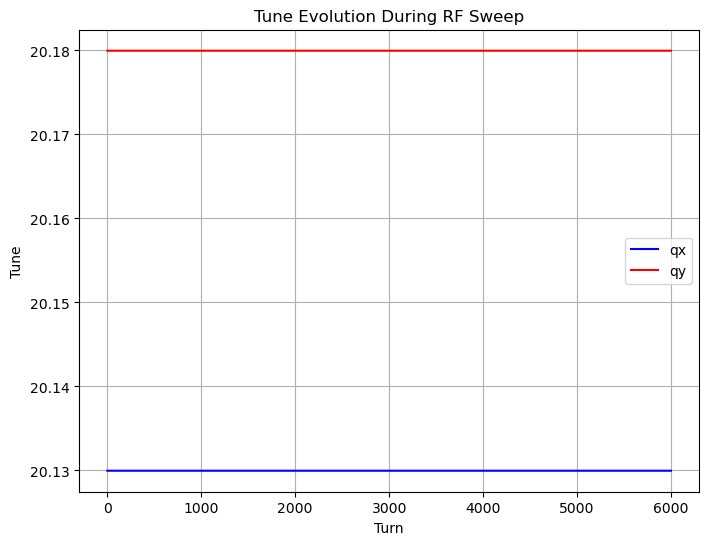

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

turns = np.arange(num_turns)

qxs = [tw.qx for tw in twisses]
qys = [tw.qy for tw in twisses]

ax.plot(turns, qxs, label='qx', color='blue')
ax.plot(turns, qys, label='qy', color='red')
ax.set_xlabel('Turn')
ax.set_ylabel('Tune')
ax.set_title('Tune Evolution During RF Sweep')
ax.legend()
ax.grid()

Conclusion is that the twiss does not change with cavity frequency

In [16]:
line['actcse.31632'].frequency

np.float64(200000001.0)

In [27]:
line = xt.load(Path('/Users/lisepauwels/phd/code/sps-xsuite-model/sps_with_aperture_inj_q20_beam_sagitta4.json'))
env = line.env
cavity_elements, cavity_names = line.get_elements_of_type(xt.Cavity)
for name in cavity_names:
    line[name].frequency = 200e6
    line[name].lag = 180
    line[name].voltage = 0
# line['acl.31735'].voltage = 0 #setting 800 cav to 0V
line['actcse.31632'].voltage = 3.0e6


env.vars['qph_setvalue'] = xi_x
env.vars['qpv_setvalue'] = xi_y
opt = line.match(
    method='6d', # <- passed to twiss
    vary=[
        xt.VaryList(['kqf0', 'kqd0'], step=1e-8, tag='quad'),
        xt.VaryList(['qph_setvalue', 'qpv_setvalue'], step=1e-4, tag='sext'),
    ],
    targets = [
        xt.TargetSet(qx=qx, qy=qy, tol=1e-6, tag='tune'),
        xt.TargetSet(dqx=xi_x*qx, dqy=xi_y*qy, tol=1e-2, tag='chrom'),
    ])


tw = line.twiss()

beta0 = line.particle_ref.beta0[0]
E = line.particle_ref.energy0[0]
q = line.particle_ref.q0
h = line['actcse.31632'].frequency * line.get_length() / beta0 / sc.c
eta = tw.slip_factor
phi = np.deg2rad(line['actcse.31632'].lag)
bucket_height = np.sqrt(abs(q*line['actcse.31632'].voltage*beta0**2 / (np.pi*h*eta*E) * (
                            2*np.cos(phi) + (2*phi-np.pi)*np.sin(phi)
                        )))

# delta_shift = -sweep_per_turn / line['actcse.31632'].frequency / eta
# bucket_turns = bucket_height * 2 / abs(delta_shift)

Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

/Users/lisepauwels/Xsuite/xtrack/xtrack/beam_elements/elements.py:2809: FutureWarning: The `Solenoid` element is deprecated. Use `VariableSolenoid` or `UniformSolenoid` instead.
  warn(


Done loading line from dict.           
                                             
Optimize - start penalty: 0.1747                            
Matching: model call n. 8 penalty = 1.7532e-04              
Optimize - end penalty:  0.000175324                            


In [26]:
line['actcse.31632'].frequency

np.float64(200000000.0)

fast sweep is qs * bucket_turns < 3 so abs(qs*bucket_turns) > 3
bucket_turns = bucket_height * 2 / abs(delta_shift)
delta_shift = -sweep_per_turn / f_RF / eta

abs(sweep_per_turn) = abs(delta_shift) * f_rf * eta
                    = bucket_height * 2 / bucket_turns
                    = bucket_height * 2 / (3/qs)

is the limit 

In [33]:
2*bucket_height / (3/tw.qs)

np.float64(2.4551111909641804e-05)

In [28]:
bucket_height

np.float64(0.002981745474219963)

In [30]:
sweep_per_turn = 1
delta_shift = -sweep_per_turn / line['actcse.31632'].frequency / eta
bucket_turns = bucket_height * 2 / abs(delta_shift)

In [32]:
bucket_turns * tw.qs

np.float64(26.419532407044684)